In [13]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [31]:
%matplotlib notebook

In [2]:
def hex_to_rgb(value):
    value = value.lstrip('#')
    lv = len(value)
    return tuple(int(value[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))

def get_PNW_cmap(palette='Starfish',n_colors = 10):

    '''Returns color map based on input string from a list. With credit to Jake Lawlor at https://github.com/jakelawlor/PNWColors/blob/master/R/PNWColors.R
    cmap: Starfish, Shuskan, Bay, Winter, Lake, Sunset, Shuskan2, Cascades, Sailboat, Moth, Spring, Mushroom, Sunset2, Anemone'''

    from matplotlib.colors import LinearSegmentedColormap as lsc
    import matplotlib as mpl
    Starfish = ['#24492e', '#015b58', '#2c6184', '#59629b', '#89689d', '#ba7999', '#e69b99']
    Shuskan = ['#33271e', '#74677e', '#ac8eab', '#d7b1c5', '#ebbdc8', '#f2cec7', '#f8e3d1', '#fefbe9']
    Bay = ['#00496f', '#0f85a0', '#edd746', '#ed8b00', '#dd4124']
    Winter = ['#2d2926', '#33454e', '#537380', '#81a9ad', '#ececec']
    Lake = ['#362904', '#54450f', '#45681e', '#4a9152', '#64a8a8', '#85b6ce', '#cde5f9', '#eef3ff']
    Sunset = ['#41476b', '#675478', '#9e6374', '#c67b6f', '#de9b71', '#efbc82', '#fbdfa2']
    Shuskan2 = ['#5d74a5', '#b0cbe7', '#fef7c7', '#eba07e', '#a8554e']
    Cascades = ["#2d4030","#516823","#dec000","#e2e260","#677e8e","#88a2b9"]
    Sailboat = ['#6e7cb9', '#7bbcd5', '#d0e2af', '#f5db99', '#e89c81', '#d2848d']
    Moth = ['#4a3a3b', '#984136', '#c26a7a', '#ecc0a1', '#f0f0e4']
    Spring = ['#d8aedd', '#bf9bdd', '#cb74ad', '#e69e9c', '#ffc3a3', '#fbe4c6']
    Mushroom = ['#4f412b', '#865a3c', '#ba783e', '#e69c4c', '#fbcc74', '#fffbda']
    Sunset2 = ['#1d457f', '#61599d', '#c36377', '#eb7f54', '#f2af4a']
    Anemone = ["#009474" ,"#11c2b5" ,"#72e1e1", "#f1f4ee" ,"#efddcf", "#dcbe9b" ,"#b0986c"]

    rgb_colors = [hex_to_rgb(c) for c in eval(palette)]
    rgb_colors = [(c[0]/255,c[1]/255,c[2]/255) for c in rgb_colors]
    cmap = lsc.from_list('cmap',rgb_colors)
    color_list = eval(palette)
    try:
        mpl.cm.register_cmap(palette, cmap)
    except:
        pass
    cp = sns.color_palette(palette,n_colors=n_colors)
    return color_list,cmap,cp

def make_color_palette(palette_name,palette,n_colors = 10):

    from matplotlib.colors import LinearSegmentedColormap as lsc
    import matplotlib as mpl

    rgb_colors = [hex_to_rgb(c) for c in palette]
    rgb_colors = [(c[0]/255,c[1]/255,c[2]/255) for c in rgb_colors]
    cmap = lsc.from_list('cmap',rgb_colors)
    color_list = palette
    try:
        mpl.cm.register_cmap(palette_name, cmap)
    except:
        pass
    cp = sns.color_palette(palette,n_colors=n_colors)
    return color_list,cmap,cp


In [9]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\analysis\derived\packaged\soma_calcium"

In [7]:
sessions = os.listdir(basepath)
for i,session in enumerate(sessions):
    print(i,session)

0 826033_2026-02-21_09-23-34
1 826033_2026-02-23_10-45-21
2 826033_2026-02-24_14-14-45
3 826033_2026-02-25_08-49-29
4 826033_2026-02-26_12-40-54
5 826033_2026-02-27_13-53-35
6 834788_2026-03-02_10-18-42
7 834788_2026-03-03_09-22-19
8 834788_2026-03-04_08-43-07
9 834788_2026-03-05_08-11-16
10 834788_2026-03-17_15-17-36
11 834788_2026-03-19_09-05-56
12 834788_2026-03-20_12-44-00
13 838410_2026-03-02_12-40-55
14 838410_2026-03-03_13-49-07
15 838410_2026-03-04_12-54-47
16 838410_2026-03-05_10-16-37
17 838410_2026-03-18_16-43-23
18 838410_2026-03-19_13-06-48
19 838410_2026-03-20_10-00-59


In [41]:
session =  sessions[8]
dmd = 2
session_meta_path = glob.glob(os.path.join(basepath,session,'session_metadata.json'),recursive=True)[0] 
stim_events_path = glob.glob(os.path.join(basepath,session,'stimulus_events.json'),recursive=True)[0]
raw_datapath = glob.glob(os.path.join(basepath,session,f'DMD{dmd}','raw_soma_calcium.npz'),recursive=True)[0]
processed_datapath = glob.glob(os.path.join(basepath,session,f'DMD{dmd}','processed_soma_calcium_dff.npz'),recursive=True)[0]

In [42]:
with open(session_meta_path, "r") as f:
    session_meta = json.load(f)
    
with open(stim_events_path, "r") as f:
    stim_events = json.load(f)

In [43]:
session_meta

{'session_id': '834788_2026-03-04_08-43-07',
 'subject_id': 834788,
 'session_dir': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\834788\\834788_2026-03-04_08-43-07',
 'summary_mat': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\834788\\834788_2026-03-04_08-43-07\\834788_2026-03-04_08-43-07_slap2_2026-03-04_08-43-07\\source_extraction\\ExperimentSummary\\SummaryLoCo-260305-101229.mat',
 'bonsai_event_log_csv': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\834788\\834788_2026-03-04_08-43-07\\834788_2026-03-04_08-43-07\\behavior\\VCO1_Behavior.harp\\bonsai_event_log.csv',
 'session_label': 'familiar',
 'sampling_rate_hz': 200.0,
 'n_trials': 65,
 'asset_metadata': {'session_id': '834788_2026-03-04_08-43-07',
  'subject_id': 834788,
  'session_#': 4,
  'session_date': '2026-03-04T00:00:00',
  'indicator1': 'iGluSnFR4',
  'indicator2': 'RCaMP3',
  'dmd1_depth': 25,
  'dmd2_dept

In [44]:
imaging_epoch = [session_meta['imaging_epochs']['session_imaging_start_time_s'],session_meta['imaging_epochs']['session_imaging_end_time_s']]
imaging_epoch

[3.9983040001243353, 1804.013248000294]

In [45]:
stim_events

{'time_source_column': 'corrected_timestamps',
 'value_source_column': 'Value',
 'n_rows': 113183,
 'n_image_events': 2363,
 'ordered_image_values': ['stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk00942.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\images_A\\imk01097.tiff',
  'stimuli\\imag

In [46]:
raw_data = np.load(raw_datapath)
processed_data = np.load(processed_datapath)

In [47]:
list(processed_data.keys())

['trial_stack',
 'session_concat',
 'trial_lengths_samples',
 'trial_start_times_s',
 'fs_hz',
 'dmd',
 'trace_kind',
 'roi_axis_name',
 'fill_length_samples',
 'n_rois',
 'n_trials']

<IPython.core.display.Javascript object>


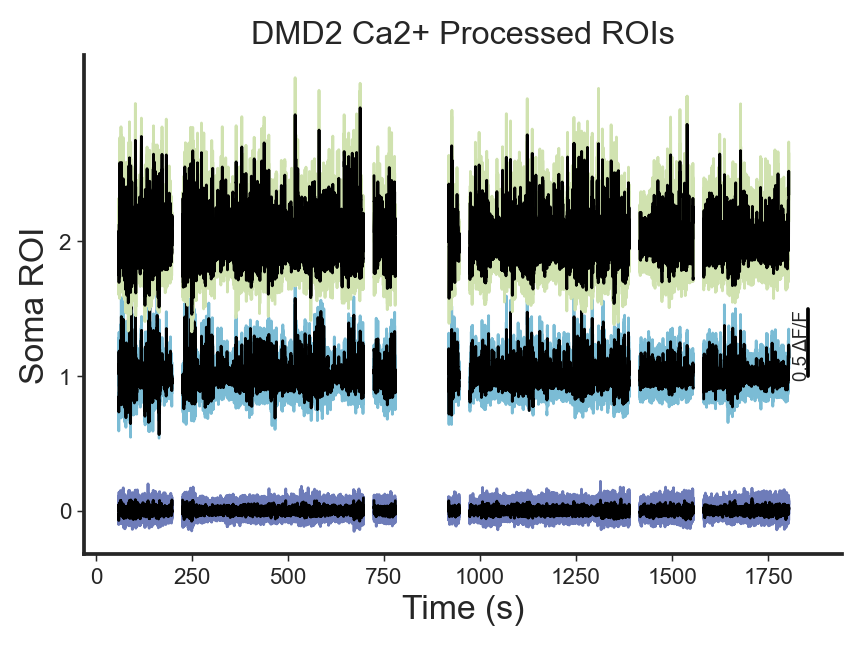

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_35076\566372277.py:33: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  mpl.cm.register_cmap(palette, cmap)


In [49]:
offset = 1

fig,ax=plt.subplots()

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

n_rois = len(processed_data['session_concat'])

cl,cmap,cp = get_PNW_cmap('Sailboat',n_colors = n_soma)

time = np.linspace(imaging_epoch[0],imaging_epoch[1],len(processed_data['session_concat'][0]))

for s,soma_trace in enumerate(processed_data['session_concat']):
    
    ax.plot(time,soma_trace+s*offset,color=cl[s])
    
    rolling = pd.DataFrame(soma_trace).rolling(25,min_periods = 1).mean()
    
    ax.plot(time,rolling+s*offset,color='k')
    
yticks = np.arange(n_rois) * offset
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(n_rois))   

ax.set_ylabel('Soma ROI', fontsize=18)
ax.set_xlabel('Time (s)', fontsize=18)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)
s_bar_pad = 50    

ax.plot([imaging_epoch[1]+s_bar_pad,imaging_epoch[1]+s_bar_pad],[1,1.5],color='k',lw=2)
ax.text(imaging_epoch[1]+s_bar_pad/5,1.0,'0.5 \u0394F/F',rotation=90)
ax.set_title(f'DMD{dmd} Ca2+ Processed ROIs')
fig.tight_layout()